# Section 5.2

## Example 5.2.1

Let's define a set of four nodes (i.e., $n=3$ in our formulas).

In [2]:
t = [0, 0.55, 0.7, 1]

4-element Vector{Float64}:
 0.0
 0.55
 0.7
 1.0

We plot the hat functions $H_0,\ldots,H_3$.

```{tip}
:class: dropdown
Use `annotate!` to add text to a plot.
```

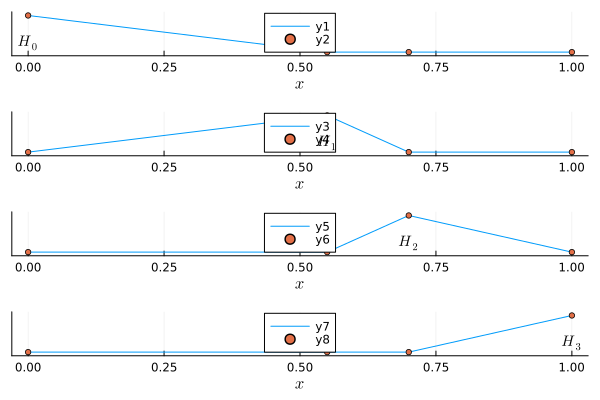

In [3]:
using Plots, FNCFunctions, LaTeXStrings

plt = plot(layout=(4, 1),  legend=:top,
    xlabel=L"x",  ylims=[-0.1, 1.1],  ytick=[])
for k in 0:3
    Hₖ = FNC.hatfun(t, k)
    plot!(Hₖ, 0, 1, subplot=k + 1)
    scatter!(t, Hₖ.(t), m=3, subplot=k + 1)
    annotate!(t[k+1], 0.25, text(latexstring("H_$k"), 10), subplot=k+1)
end
plt

## Example 5.2.2

We generate a piecewise linear interpolant of $f(x)=e^{\sin 7x}$.

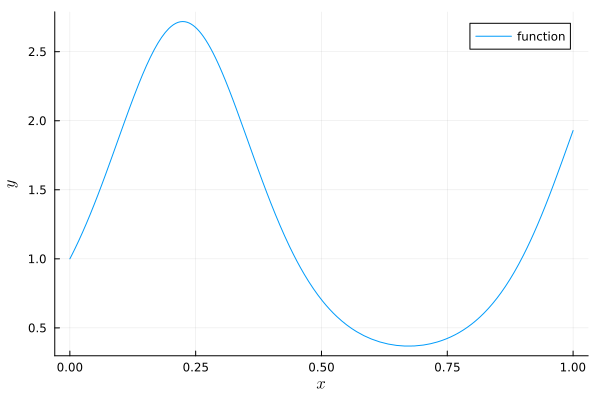

In [4]:
using Plots, LaTeXStrings

f(x) = exp(sin(7x))

plot(f, 0, 1, label="function", xlabel=L"x", ylabel=L"y")

First we sample the function to create the data.

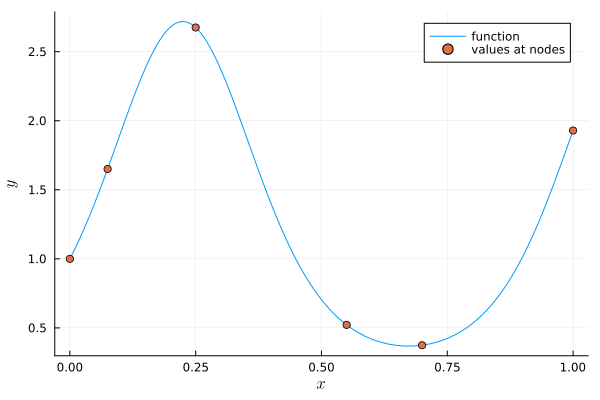

In [5]:
t = [0, 0.075, 0.25, 0.55, 0.7, 1]    # nodes
y = f.(t)                             # function values
scatter!(t, y, label="values at nodes")

Now we create a callable function that will evaluate the piecewise linear interpolant at any $x$, and then plot it.

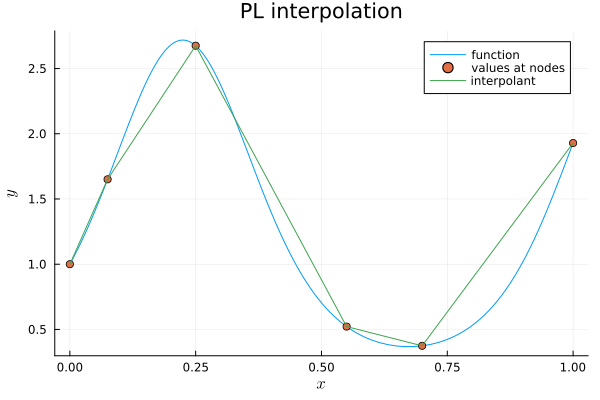

In [6]:
using FNCFunctions

p = FNC.plinterp(t, y)
plot!(p, 0, 1, label="interpolant", title="PL interpolation")

## Example 5.2.3

We measure the convergence rate for piecewise linear interpolation of $e^{\sin 7x}$ over $x \in [0,1]$.

In [13]:
using FNCFunctions, PrettyTables, LinearAlgebra

f(x) = exp(sin(7x))
x = range(0, 1, 10001)  # sample the difference at many points
n = @. round(Int, 10^(1:0.25:3.5))
maxerr = zeros(length(n))
for (k, n) in enumerate(n)
    t = (0:n) / n    # interpolation nodes
    p = FNC.plinterp(t, f.(t))
    err = @. f(x) - p(x)
    maxerr[k] = norm(err, Inf)
end

pretty_table((n=n[1:4:end], err=maxerr[1:4:end]);
    column_labels=["n", "max-norm error"], backend=:html)

n,max-norm error
10,0.150471
100,0.00166421
1000,1.66494e-5


As predicted, a factor of 10 in $n$ produces a factor of 100 in the error. In a convergence plot, it is traditional to have $h$ *decrease* from left to right, so we expect a straight line of slope $-2$ on a log-log plot.

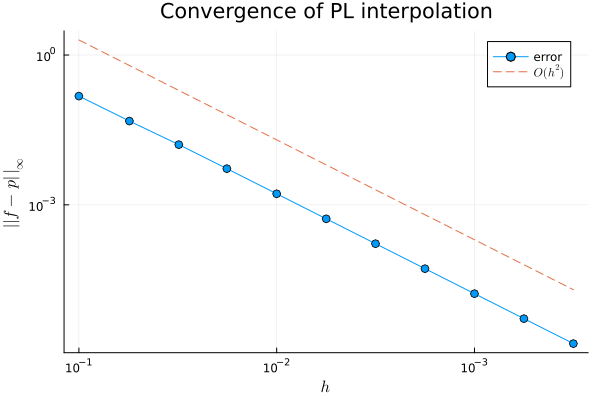

In [16]:
using Plots, LaTeXStrings

h = @. 1 / n
order2 = @. 2 * (h / h[1])^2

plot(h, maxerr, m=:o, label="error", xflip=true)
plot!(h, order2;
    l=:dash,  label=L"O(h^2)",
    xaxis=(:log10, L"h"),  yaxis=(:log10, L"|| f-p\, ||_\infty"),
    title="Convergence of PL interpolation")